# Yolo Object Detector

In this jupyter notebook, we will implementation a basic version of Yolo.

In [1]:
import time
import os

import torch
import torchvision
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchsummary import summary

from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision.utils import make_grid
from torchvision.transforms import v2 as T
from torchvision.transforms.v2 import functional as TF
from torchvision import models, datasets
from torchvision import tv_tensors

from tqdm.notebook import tqdm

import einops
import numpy as np
from matplotlib import pyplot as plt
from random import randint

import torchvision.datasets as dset
import json
from PIL import Image, ImageDraw

from itertools import product

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Loading the Dataset
The Pascal VOC dataset contains thousands of annotated images featuring a variety of common objects across 20 categories, such as cars, bicycles, and dogs. Each image is labeled with precise bounding boxes that indicate the location of objects, along with class labels.

Before we load in the actual dataset, we specify some important parameters:

`S`: The number of cells we break our image into along the x and y axis (so this gives us an `S x S` grid with $S^2$ cells total).

`B`: The number of detections per cell (we let our model predict up to `B` boxes per cell since it's possible multiple objects are centered in the same cell)

`C`: The number of classes that each object in this dataset could belong to (Pascal VOC has 20 labels)


In [3]:
S, B, C = 7, 2, 20

#### Format of Ground Truth Labels and Model Predictions

In our object detection framework, each image is divided into an \( S X S \) grid (49 cells in our case). For each cell, we predict up to \( B \) bounding boxes (2 in our case). Each bounding box prediction includes the center coordinates \((x, y)\), represented as proportions of the cell's dimensions, along with the box width \( w \) and height \( h \), which are expressed as proportions of the full image size.

Additionally, we assign a confidence score to each box, indicating the model's certainty that an object exists within that box; this score ranges from 0 to 1. Furthermore, we predict the class label as a vector of probabilities of length \( C \), corresponding to the potential object classes. Notably, we predict one class per cell rather than per bounding box, a design choice in YOLO that effectively limits each cell to detect a single object.

#### Rationale for Predicting Multiple Boxes per Cell

The rationale for predicting multiple bounding boxes per cell, despite them being tied to the same object/class, is to allow for specialization in the predictions. For instance, one box may become adept at identifying tall objects, while another may excel at recognizing wider shapes. This approach enables the model to select the most appropriate bounding box during inference, based on its shape.

Consequently, for each prediction on an image, we generate  `B` bounding boxes along with a `C`-length vector of class probabilities for every cell in our `SxS` grid. Each bounding box consists of five components: the confidence score `s`, and the bounding box center coordinates `x` and `y` (relative to the cell), along with the bounding box width `w` and height `h` (relative to the image). Therefore, for each cell, we output a vector of size `5B + C`. The final output for a single image thus has a shape of `(S, S, 5B + C)`. When processing a batch of images, the output dimensions are `(batch_size, S, S, 5B + C)`.

## Pascal VOC Dataset
The Pascal VOC 2012 dataset is a key benchmark in computer vision, particularly in object detection, semantic segmentation, and classification tasks. It includes 11,530 images annotated with objects from 20 diverse categories, such as animals (e.g., dog, cat), vehicles (e.g., car, bus), and household items (e.g., chair, dining table).

Images in Pascal VOC 2012 vary in size but are typically around 500x375 pixels. They are annotated with both bounding boxes for object detection and detailed pixel-level segmentation masks.

In [4]:
data_root = './data/voc'
train_size = 2304 * 4
val_size = 2304

dataset = torchvision.datasets.VOCDetection(
    root=data_root,
    year='2012',
    image_set='trainval',
    download=True,
    transform=None,
)
assert train_size + val_size <= len(dataset), "Trying to sample too many elements!" \
                                              "Please lower the train or validation set sizes."

train_temp_set = torch.utils.data.Subset(dataset, range(train_size))
val_temp_set = torch.utils.data.Subset(dataset, range(train_size, train_size + val_size))

100%|██████████| 2.00G/2.00G [01:17<00:00, 25.8MB/s]


Extracting ./data/voc/VOCtrainval_11-May-2012.tar to ./data/voc


In [5]:
class VOCDataset(Dataset):
    def __init__(self, orig_dataset, classes, transform=None):
      self.orig_dataset = orig_dataset
      self.classes = classes
      self.transform = transform

    def __len__(self):
        return len(self.orig_dataset)

    def _get_normalised_box(self, idx, obj, img_size: tuple[int, int]):
        """
        The VOCDataset has boxes in an xmin, ymin, xmax, ymax format, but we need our boxes
        to be in the YOLO format which is an (x, y) representing the center and
        the width and height of the box.
        We return the converted box and the cell (x, y) which the box is centered in
        """
        x_min, y_min, x_max, y_max = obj

        cell_width, cell_height = img_size[0] / S, img_size[1] / S

        box_center_x, box_center_y = (x_max - x_min) / 2 + x_min, (y_max - y_min) / 2 + y_min
        cell_num_x, cell_num_y = int(box_center_x // cell_width), int(box_center_y // cell_height)
        assert cell_num_x < S and cell_num_y < S, f"Box is out of bounds!, {idx, x_min, y_min, x_max, y_max, box_center_x, cell_width, box_center_y, cell_height}"

        box_x, box_y = (box_center_x % (cell_width)) / cell_width , (box_center_y % cell_height) / cell_height
        box_w, box_h = (x_max - x_min) / img_size[0], (y_max - y_min) / img_size[1]
        box = torch.tensor([box_x, box_y, box_w, box_h])

        return box, (cell_num_y, cell_num_x)

    def __getitem__(self, idx):
        """
        We need a way to go from an index to the data we want!
        We return a normalized img formatted as a tensor
        And, we want our labels in shape (S, S, 5 * B + C)
        """
        img, label = self.orig_dataset[idx]
        img = T.ToTensor()(img)

        boxes = [[int(obj["bndbox"][i]) for i in ["xmin", "ymin", "xmax", "ymax"]] for obj in label["annotation"]["object"]]
        boxes = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=img.shape[-2:])
        classes = [obj["name"] for obj in label["annotation"]["object"]]

        if self.transform:
            img, boxes = self.transform(img, boxes)

        onehot_ls = torch.eye(len(self.classes))
        one = torch.tensor([1])

        out = torch.zeros((S, S, 5 * B + len(self.classes)))

        bboxes = {}

        for obj_name, box_ in zip(classes, boxes):
            x_min, y_min, x_max, y_max = box_
            if x_min >= x_max or y_min >= y_max:
                continue

            box, (y, x) = self._get_normalised_box(idx, box_, (img.shape[-1], img.shape[-2]))

            detection_zone = out[y][x]

            class_probs = onehot_ls[self.classes.index(obj_name)]
            detection_zone[5*B:] = class_probs

            bbox_id = bboxes.get((y, x), 0)
            if bbox_id < B:
                bboxes[(y, x)] = bbox_id + 1
                for i in range(bbox_id, B):
                    detection_zone[5*i:5*(i+1)] = torch.concat([one, box], dim=-1)

        return img, out

In [6]:
image_size = 224

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

train_transform = T.Compose([
    T.Resize((image_size, image_size), antialias=True),
    T.ColorJitter(saturation=0.1, hue=0.1),
    T.RandomHorizontalFlip(),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=0),
    T.Normalize(mean, std)
])

valid_transform = T.Compose([
    T.Resize((image_size, image_size), antialias=True),
    T.Normalize(mean, std)
])

unnormalize = T.Normalize((-mean / std), (1.0 / std))

classes = ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
          'bus', 'car', 'cat', 'chair', 'cow',
          'diningtable', 'dog', 'horse', 'motorbike', 'person',
          'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

train_set = VOCDataset(train_temp_set, classes, train_transform)
val_set = VOCDataset(val_temp_set, classes, valid_transform)

print(f"Length of train dataset {len(train_set)} , Length of validation dataset {len(val_set)}")

Length of train dataset 9216 , Length of validation dataset 2304


## Visualise the dataset



In [7]:
images_to_plot = []
bboxes_ls_list = []
classes_ls_list = []
scores_ls_list = []

def retrieve_bboxes(bboxes):
    boxes_ls, classes_ls, scores_ls = [], [], []

    cell_size = image_size / S

    for sy in range(S):
        for sx in range(S):
            cell = bboxes[sy][sx]
            for b in range(B):
                if cell[5 * b] > 0.0:    # ignore no confidence predictions
                    class_num = torch.argmax(cell[5*B:], dim=-1)
                    class_label = classes[class_num]
                    classes_ls.append(class_label)
                    scores_ls.append(cell[5 * b])
                    # xy are normalised by cell size and lw are normalised by image size
                    y1 = cell_size * (sy + cell[5 * b + 2]) - (image_size * cell[5 * b + 4] / 2)
                    x1 = cell_size * (sx + cell[5 * b + 1]) - (image_size * cell[5 * b + 3] / 2)
                    y2 = y1 + image_size * cell[5 * b + 4]
                    x2 = x1 + image_size * cell[5 * b + 3]
                    xyxy = [x1, y1, x2, y2]
                    boxes_ls.append(xyxy)
    return boxes_ls, classes_ls, scores_ls

def plot_images(images, bboxes_ls_list, classes_ls_list, scores_ls_list):
    num_images = len(images)
    fig, axs = plt.subplots(3, 3, figsize=(10, 10))

    for i in range(9):
        image = images[i]
        bboxes_ls = bboxes_ls_list[i]
        classes_ls = classes_ls_list[i]
        scores_ls = scores_ls_list[i]
        img = unnormalize(image)
        img = T.Resize((224, 224), antialias=True)(img)
        img = T.ToPILImage()(img)
        draw = ImageDraw.Draw(img)

        for box, class_, score in zip(bboxes_ls, classes_ls, scores_ls):
            box = [i * 224 / image_size for i in box]
            draw.rectangle(box, outline=(255, 0, 0))
            box_text = f" {class_} {score:4.2f} "
            annotation_pos = (box[0], box[1] - 11)
            annotation_box = draw.textbbox(annotation_pos, box_text)
            draw.rectangle(annotation_box, fill=(255, 0, 0), outline=(255, 0, 0))
            draw.text(annotation_pos, box_text, fill=(255, 255, 255))
        axs[i // 3, i % 3].imshow(img)
        axs[i // 3, i % 3].axis('off')
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


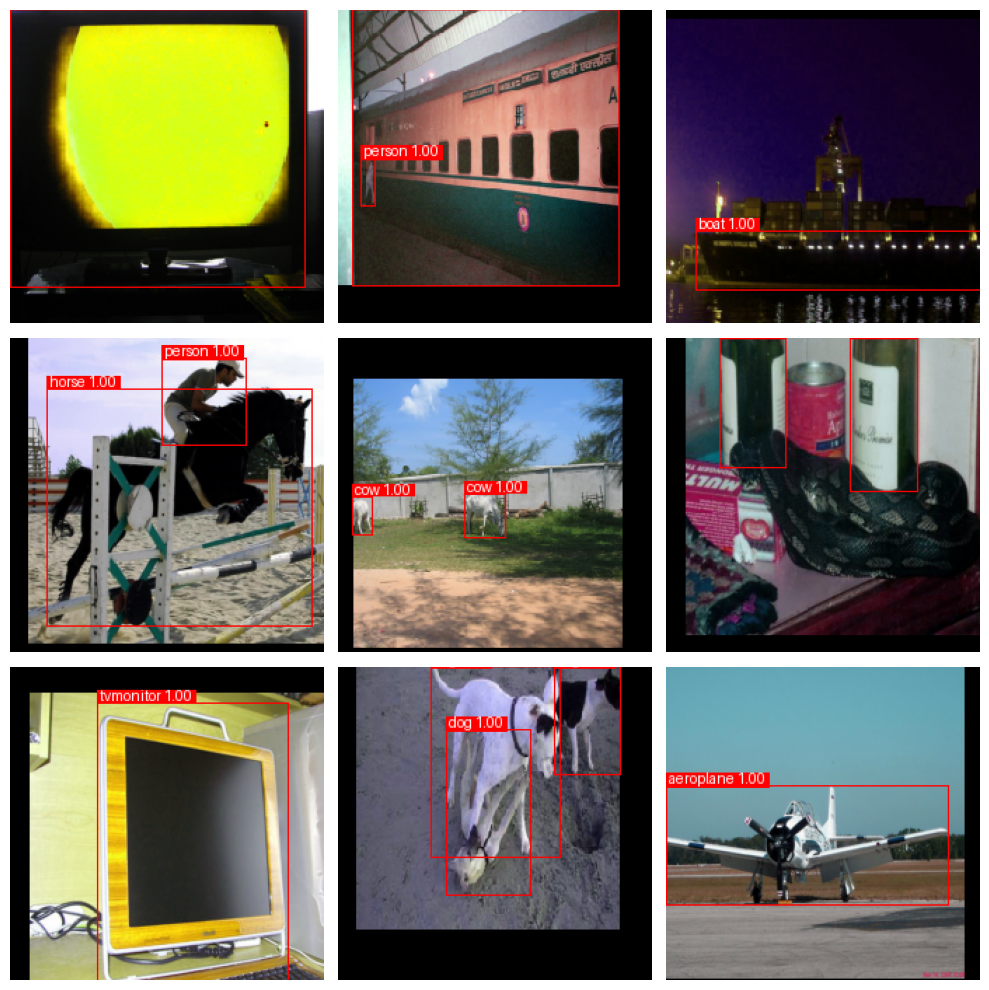

In [8]:
for i in range(9):
    images, bboxes = train_set[i]
    bboxes_ls, classes_ls, scores_ls = retrieve_bboxes(bboxes)
    images_to_plot.append(images)
    bboxes_ls_list.append(bboxes_ls)
    classes_ls_list.append(classes_ls)
    scores_ls_list.append(scores_ls)

plot_images(images_to_plot, bboxes_ls_list, classes_ls_list, scores_ls_list)

## YOLO for Object Detection

In this section, we’ll explore the **You Only Look Once (YOLO)** architecture. YOLO transforms the problem into a single regression task, enabling real-time object detection by using a single convolutional network to predict bounding boxes and class probabilities simultaneously.

### Confidence in YOLO
A key concept in YOLO is confidence. The confidence value represents how confident the model is that a predicted bounding box accurately covers an object. This is closely tied to the Intersection over Union (IoU) between the predicted bounding box and the ground truth box.

What is Confidence in YOLO?
In YOLO, the confidence of a bounding box prediction is defined as: *Confidence = IoU with the ground truth box*

#### Behavior Based on Object Presence:
- **No Ground Truth Box (No Object)**: If a bounding box does not correspond to any object (i.e., there is no ground truth box that matches the prediction), the confidence will be 0.
- **Ground Truth Box Exists**: If there is a corresponding ground truth box, the confidence is based on the IoU. The higher the IoU (more overlap), the higher the confidence. This helps the model focus on predicting bounding boxes that are more accurate.

#### Why Confidence Matters
The confidence score helps YOLO filter out poor predictions:
 - A high confidence score means the predicted box is likely correct.
 - A low confidence score suggests the box is not accurate, and the model can ignore it.

### Training vs. Inference Time
 - **During Training**: YOLO selects one bounding box as the "predictor" for each object. This box is responsible for predicting that object, and the rest are ignored. The IoU between the predicted box and the ground truth determines which box gets selected as the predictor.
 - **During Inference**: YOLO uses Non-Maximum Suppression (NMS) to remove redundant boxes that overlap heavily with a higher-confidence box, ensuring only the most accurate predictions are kept.

### Defining Box and Cell Masks
YOLO also uses two key tensors: box_mask and cell_mask. These help manage which bounding boxes are responsible for predicting each object.

#### Box Mask (Shape: S, S, B):
The box_mask tensor indicates which bounding box in each cell is the "predictor" for a specific object. If the k-th bounding box in cell (i, j) is selected as the predictor, then: `box_mask[i, j, k] = 1`. Otherwise, it is set to 0.

**Why is Box Mask Important?**
During training, only the designated "predictor" bounding box is penalized in the loss function. This reduces noise and ensures the model learns to predict only one box for each object in each cell.

#### Cell Mask (Shape: S, S):
The cell_mask tensor tells us which cells contain an object centered within them. If cell (i, j) contains an object, then: `cell_mask[i, j] = 1`. Otherwise, it is set to 0.

**Why is Cell Mask Important?**
The cell_mask helps YOLO focus on predicting objects that are centered within specific grid cells, reducing unnecessary predictions in empty cells.

### Computing IoU Between Predicted and Ground Truth Boxes
For training and confidence calculation, YOLO needs to compute the Intersection over Union (IoU) between the predicted and ground truth bounding boxes.

#### What is IoU?
IoU is a measure of the overlap between two bounding boxes. It is calculated as:
```
IoU = Area of Intersection / Area of Union
```
#### Why IoU Matters?
The IoU score tells us how well the predicted box matches the ground truth box. A higher IoU means a better match, which directly translates into a higher confidence score.

### Training YOLO: Focused Learning on the "Predictor"
During training, YOLO only penalizes the bounding box selected as the "predictor" for an object. The predictor is chosen based on the highest IoU with the ground truth box. All other bounding boxes in the same cell are ignored during the loss computation.

This approach helps the model focus on learning the most accurate bounding box for each object, which improves training efficiency.

In [9]:
def batched_iou(preds, labels):
    """
    Compute the pairwise IOU between the predicted bounding boxes and the ground truth bounding boxes for each cell.

    param: preds is tensor of shape (N, S, S, 5B + C)
    param: labels is a tensor of shape (N, S, S, 5B + C)

    returns: tensor of shape (N, S, S, B, B) containing the pairwise IOU between the predicted bounding boxes and the ground truth bounding boxes for each cell
    """
    N = labels.shape[0]

    x_labels, x_preds = labels[:, :, :, 1:5*B:5], preds[:, :, :, 1:5*B:5]
    y_labels, y_preds = labels[:, :, :, 2:5*B:5], preds[:, :, :, 2:5*B:5]
    w_labels, w_preds = labels[:, :, :, 3:5*B:5], preds[:, :, :, 3:5*B:5]
    h_labels, h_preds = labels[:, :, :, 4:5*B:5], preds[:, :, :, 4:5*B:5]

    cell_size = image_size / S
    # retrieve the coordinates of the bounding box rectangles for the labels
    x1_labels = cell_size * (x_labels + einops.repeat(torch.arange(S, device=labels.device), "S2 -> N S1 S2 B", N=N, S1=S, B=B)) - (image_size * w_labels / 2)
    y1_labels = cell_size * (y_labels + einops.repeat(torch.arange(S, device=labels.device), "S1 -> N S1 S2 B", N=N, S2=S, B=B)) - (image_size * h_labels / 2)
    x2_labels = x1_labels + image_size * w_labels
    y2_labels = y1_labels + image_size * h_labels
    # retrieve the coordinates of the bounding box rectangles for the predictions
    x1_preds = cell_size * (x_preds + einops.repeat(torch.arange(S, device=labels.device), "S2 -> N S1 S2 B", N=N, S1=S, B=B)) - (image_size * w_preds / 2)
    y1_preds = cell_size * (y_preds + einops.repeat(torch.arange(S, device=labels.device), "S1 -> N S1 S2 B", N=N, S2=S, B=B)) - (image_size * h_preds / 2)
    x2_preds = x1_preds + image_size * w_preds
    y2_preds = y1_preds + image_size * h_preds

    # compute the top left and bottom right corners of the rectangles
    tl_labels = torch.stack([x1_labels, y1_labels], dim=-1)
    br_labels = torch.stack([x2_labels, y2_labels], dim=-1)
    tl_preds = torch.stack([x1_preds, y1_preds], dim=-1)
    br_preds = torch.stack([x2_preds, y2_preds], dim=-1)

    # Largest top-left corner and smallest bottom-right corner give the intersection
    tl = torch.max(
        einops.repeat(tl_preds,  "N S1 S2 B1 D -> N S1 S2 B1 B2 D", B2=B),        # (N, S, S, B, 1, 2) -> (N, S, S, B, B, 2)
        einops.repeat(tl_labels, "N S1 S2 B2 D -> N S1 S2 B1 B2 D", B1=B)         # (N, S, S, 1, B, 2) -> (N, S, S, B, B, 2)
    )
    br = torch.min(
        einops.repeat(br_preds,  "N S1 S2 B1 D -> N S1 S2 B1 B2 D", B2=B),        # (N, S, S, B, 1, 2) -> (N, S, S, B, B, 2)
        einops.repeat(br_labels, "N S1 S2 B2 D -> N S1 S2 B1 B2 D", B1=B)         # (N, S, S, 1, B, 2) -> (N, S, S, B, B, 2)
    )

    intersection_sides = torch.clamp(br - tl, min=0.0)
    intersection = intersection_sides[..., 0] * intersection_sides[..., 1]       # (N, S, S, B, B)

    area_preds = (w_preds * image_size) * (h_preds * image_size)
    area_preds = einops.repeat(area_preds, "N S1 S2 B1 -> N S1 S2 B1 B2", B2=B)

    area_labels = (w_labels * image_size) * (h_labels * image_size)
    area_labels = einops.repeat(area_labels, "N S1 S2 B2 -> N S1 S2 B1 B2", B1=B)

    union = area_labels + area_preds - intersection

    # Add a small non-zero constant to avoid division-by-zero errors
    union += 1e-6

    return intersection / union

In [10]:
def create_masks(preds, labels):
    """
    Create the cell and box masks based on the IOU.

    param: preds is tensor of shape (N, S, S, 5B + C)
    param: labels is a tensor of shape (N, S, S, 5B + C)
    """
    N = labels.shape[0]

    iou = batched_iou(preds, labels) # (N, S, S, B, B)
    preds = preds[:, :, :, :5*B]
    labels = labels[:, :, :, :5*B]

    # iou[..., i, j] gives the IOU between ith prediction box and jth label box
    # take the max over all label boxes to get the cloest label box to a prediction box
    iou, _ = torch.max(iou, dim=-1) # (N, S, S, B)

    # 1 if bounding box is "responsible" for predicting the object
    responsible = torch.zeros(N, S, S, B, device=labels.device).scatter_(-1, torch.argmax(iou, dim=-1, keepdim=True), value=1)

    # 1 if cell contains an object and otherwise
    conf_labels = labels[:, :, :, 0::5] > 0.0
    cell_mask = conf_labels[..., 0]

    # 1 if box contains an object and is responsible for it
    box_mask = responsible * conf_labels

    return iou, cell_mask, box_mask

Now that we have uniquely formulated the object detection problem, we will introduce the loss function that YOLO optimizes. It has three components and we will step through each one:

**Classification Loss**: If a cell contains an object, we take the squared error between the class probabiities the model predicts for said cell vs the ground truth labels (which will be a one-hot vector). We add up this squared error for all cells that contain an object. Mathematically, this *classification loss* is given by
$$
l_{\text{classification}} = \sum_{i=0}^{S-1} \sum_{j=0}^{S-1} \mathbb 1_{ij}^{\text{obj}} \sum_{c \in \text{classes}} (p_{ij}(c) - \hat{p}_{ij}(c))^2
$$
where
* $\mathbb 1_{ij}^{\text{obj}}$ is $1$ if cell $(i, j)$ should detect an object, otherwise $0$ --- this is precisely the value given by `cell_mask[i, j]`
* $\hat{p}_{ij}(c)$ is the class probability, predicted by the model, of the object in cell $(i, j)$ belonging to class $c$
* $p_{ij}(c)$ is the class probability, according to the ground truth label, of the object in cell $(i, j)$ belonging to class $c$


In [11]:
def l_classification(preds, labels, cell_mask):
    """
    Compute the classification loss as described above.

    param: preds is tensor of shape (N, S, S, 5B + C)
    param: labels is a tensor of shape (N, S, S, 5B + C)
    param: cell_mask is a tensor of shape (N, S, S)

    Here N is the batch size.
    Refer to the discussion above for more info on the prediction/label format.

    Along the last dimension for both tensors (i.e. for a specific cell of a specific image):
    1. the first 5B elements can be divided into B groups of 5 elements each, with each group representing a bounding box for a particular class
       in particular, each 5 element tuple, in order, will be the (confidence, x, y, w, h) for a bounding box
    2. the last C elements are class probabilities

    Note: for the ground truth labels, the class probabilities will be one-hot encoded.
    """
    class_labels = labels[:, :, :, 5*B: ]    # (N, S, S, C) tensor of class probabilities
    class_preds = preds[:, :, :, 5*B: ]    # (N, S, S, C) tensor of class probabilities
    class_l = torch.sum((class_labels - class_preds)**2, dim=-1)    # squared errors of the probabilities (N, S, S) tensor
    class_l = cell_mask * class_l
    ## sum up the masked squared errors across along each grid cell across all N predictions in the batch
    return torch.sum(class_l)

**Localisation Loss**: If a bounding box is responsible for detecting an object, we take the squared error of its position and size predictions with respect to the true bounding box in the ground truth label. Remember that the problem of predicting an object's bounding box size and position is also known as object localization. As such, this loss component is also called *localization loss* and is given mathematically by:
$$
\begin{aligned}
l_{\text{localisation}} &= \sum_{i=0}^{S - 1} \sum_{j=0}^{S - 1} \sum_{k=0}^{B - 1} \mathbb 1_{ijk}^{\text{obj}} \left[(x_{ijk} - \hat{x}_{ijk})^2 + (y_{ijk} - \hat{y}_{ijk})^2 + \left( \sqrt{w_{ijk}} - \sqrt{\hat{w}_{ijk}} \right)^2 + \left( \sqrt{h_{ijk}} - \sqrt{\hat{h}_{ijk}} \right)^2 \right]
\end{aligned}
$$
where
* $\mathbb 1_{ijk}^{\text{obj}}$ is $1$ if the $k$th boundary box in cell $(i, j)$ is responsible for detecting the object, otherwise $0$ --- this is precisely the value given by `box_mask[i, j, k]`
* $(\hat{x}_{ijk}, \hat{y}_{ijk}, \hat{w}_{ijk}, \hat{h}_{ijk})$ are the center coordinates and spatial dimensions of the $k$th bounding box in cell $(i, j)$ according to the model predictions
* $(x_{ijk}, y_{ijk}, w_{ijk}, h_{ijk})$ are the center coordinates and spatial dimensions of the $k$th bounding box in cell $(i, j)$ according to the ground truth labels

In [12]:
def l_localization(preds, labels, box_mask):
    """
    Compute the localization loss as described above.

    param: preds is tensor of shape (N, S, S, 5B + C)
    param: labels is a tensor of shape (N, S, S, 5B + C)
    param: box_mask is a tensor of shape (N, S, S, B)

    Here N is the batch size.
    Refer to the discussion above for more info on the prediction/label format.

    Along the last dimension for both tensors (i.e. for a specific cell of a specific image):
    1. the first 5B elements can be divided into B groups of 5 elements each, with each group representing a bounding box for a particular class
       in particular, each 5 element tuple, in order, will be the (confidence, x, y, w, h) for a bounding box
    2. the last C elements are class probabilities
    """
    ## extract the (N, S, S, B) tensor of bounding box x-coordinates from the labels and predictions
    x_labels, x_preds = labels[:, :, :, 1:5*B:5], preds[:, :, :, 1:5*B:5]
    ## compute the squared errors between the x-coordinates
    x_l = (x_labels - x_preds)**2    # (N, S, S, B) tensor

    ## extract the (N, S, S, B) tensor of bounding box y-coordinates from the labels and predictions
    y_labels, y_preds = labels[:, :, :, 2:5*B:5], preds[:, :, :, 2:5*B:5]
    ## compute the squared errors between the y-coordinates
    y_l = (y_labels - y_preds)**2    # (N, S, S, B) tensor

    ## extract the (N, S, S, B) tensor of bounding box widths from the labels and predictions
    w_labels, w_preds = labels[:, :, :, 3:5*B:5], preds[:, :, :, 3:5*B:5]
    ## compute the squared errors between the square root of the widths
    w_l = (torch.sqrt(w_labels) - torch.sqrt(w_preds))**2    # (N, S, S, B) tensor

    ## extract the (N, S, S, B) tensor of bounding box heights from the labels and predictions
    h_labels, h_preds = labels[:, :, :, 4:5*B:5], preds[:, :, :, 4:5*B:5]
    ## compute the squared errors between the square root of the heights (hint: this should give you an )
    h_l = (torch.sqrt(h_labels) - torch.sqrt(h_preds))**2    # (N, S, S, B) tensor

    ## add the squared errors above to get the overall unmasked localization error per bounding box
    box_l = x_l + y_l + w_l + h_l    # (N, S, S, B) tensor
    ## apply the box_mask to box_l
    box_l = box_mask * box_l
    ## sum up the masked squared errors across along all bounding boxes along each grid cell across all N predictions in the batch
    return torch.sum(box_l)

**Confidence Loss**: We take the squared error between the confidence of each predicted box and its target confidence (this target is the IOU said box achieves with the corresponding ground truth bounding box if the box is designated as a predictor and 0 otherwise).

We compute two loss terms: the first term only contains the squared errors of the predicted boxes that are designated as responsible for bounding an object and the second term contains everything else. We return two terms because we want to weight the contribution of each term to the overall loss differently.
$$
\begin{aligned}
l_{\text{confidence\_obj}} &= \sum_{i=0}^{S - 1} \sum_{j = 0}^{S - 1} \sum_{k=0}^B \mathbb 1_{ijk}^{\text{obj}} (s_{ijk} - \hat{s}_{ijk})^2 \\
l_{\text{confidence\_no\_obj}} &= \sum_{i=0}^{S - 1} \sum_{j = 0}^{S - 1} \sum_{k=0}^B \mathbb 1_{ijk}^{\text{no\_obj}} (s_{ijk} - \hat{s}_{ijk})^2
\end{aligned}
$$

where
* $\hat{s}_{ijk}$ is the box confidence score of the $k$th box in cell $(i, j)$ and $s_{ijk}$ is the IOU it is trying to predict, as mentioned at the beginning of this section
* $\mathbb 1_{ijk}^{\text{obj}}$ is $1$ if the $k$th boundary box in cell $(i, j)$ is responsible for detecting the object, otherwise $0$ --- this is precisely the value given by `box_mask[i, j, k]`
* $\mathbb 1_{ij}^{\text{no\_obj}}$ = 1 - $\mathbb 1_{ij}^{\text{obj}}$ is the complement of $1_{ij}^{\text{obj}}$

In [13]:
def l_confidence(preds, ious, box_mask):
    """
    Compute both confidence loss terms as described above.

    param: preds is tensor of shape (N, S, S, 5B + C)
    param: ious is a tensor of shape (N, S, S, B)
    param: box_mask is a tensor of shape (N, S, S, B)

    Here N is the batch size.
    Refer to the discussion above for more info on the prediction/label format.

    Along the last dimension for both tensors (i.e. for a specific cell of a specific image):
    1. the first 5B elements can be divided into B groups of 5 elements each, with each group representing a bounding box for a particular class
       in particular, each 5 element tuple, in order, will be the (confidence, x, y, w, h) for a bounding box
    2. the last C elements are class probabilities
    """
    ## extract the (N, S, S, B) tensor of bounding box confidence scores from the predictions
    s_preds =  preds[:, :, :, 0:5*B:5]

    ## compute the squared errors between the confidence scores and the ious
    s_l_obj = (ious - s_preds)**2    # (N, S, S, B) tensor
    ## compute the squared errors between the confidence scores and a zero tensor in the shape of ious
    s_l_no_obj = (torch.zeros_like(ious) - s_preds)**2

    s_l_obj = s_l_obj * box_mask
    s_l_no_obj = s_l_no_obj * (1 - box_mask)

    return torch.sum(s_l_obj), torch.sum(s_l_no_obj)

We can now compute the overall loss as the weighted sum of each of the loss terms above:
$$
\begin{aligned}
l = l_{\text{classification}} + \lambda_{\text{coord}} l_{\text{localization}} + l_{\text{confidence\_obj}} + \lambda_{\text{no\_obj}}l_{\text{confidence\_no\_obj}}
\end{aligned}
$$
where
* $\lambda_{\text{coord}}$ is some hyperparameter that scales the contribution of the localization loss to the overall loss term. In this case, we set it to $5$ to **increase** the weight of this loss term since predicting accurate bounding box coordinates is very important in object detection.

* $\lambda_{\text{no\_obj}}$ is used to **decrease** the weight when detecting the background (i.e. boxes not resposible for predicting an object) instead of an object

We will also return each of the 3 loss components above so we can log them during training.

In [14]:
def yolo_loss(preds, labels, lambda_coord=5, lambda_no_obj=0.5):
    with torch.no_grad():
        ious, cell_mask, box_mask = create_masks(preds, labels)

    class_l = l_classification(preds, labels, cell_mask)
    local_l = lambda_coord * l_localization(preds, labels, box_mask)
    conf_l_obj, conf_l_no_obj = l_confidence(preds, ious, box_mask)
    conf_l = conf_l_obj + lambda_no_obj * conf_l_no_obj

    return class_l + local_l + conf_l, class_l, local_l, conf_l

## Training anf Evaluation

In [15]:
def eval(model, criterion, loader):
    total_overall_loss = 0
    total_class_loss = 0
    total_local_loss = 0
    total_conf_loss = 0

    model = model.to(device)
    model.eval()

    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            overall_loss, class_loss, local_loss, conf_loss = criterion(outputs, labels)
            total_overall_loss += overall_loss.item()
            total_class_loss += class_loss.item()
            total_local_loss += local_loss.item()
            total_conf_loss += conf_loss.item()
    total_items = len(loader.dataset)
    return total_overall_loss / total_items, total_class_loss / total_items, total_local_loss / total_items, total_conf_loss / total_items

In [16]:
def train(model, train_loader, val_loader, num_epochs, criterion, optimizer, path=None, scheduler=None):
    print('beginning to train model')
    if path and not os.path.exists(path):
        os.makedirs(path)

    model = model.to(device)

    best_val_loss = float('inf')

    for epoch in tqdm(range(1, num_epochs + 1)):
        model.train()
        total_overall_loss = 0
        total_class_loss = 0
        total_local_loss = 0
        total_conf_loss = 0
        start_time = time.perf_counter()

        for i, (inputs, labels) in enumerate(tqdm(train_loader, leave=False)):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            overall_loss, class_loss, local_loss, conf_loss = criterion(outputs, labels)
            overall_loss.backward()
            optimizer.step()
            total_overall_loss += overall_loss.item()
            total_class_loss += class_loss.item()
            total_local_loss += local_loss.item()
            total_conf_loss += conf_loss.item()

        if path:
            torch.save(model.state_dict(), f'{path}/model_ep_{epoch:02d}.pth')

        end_time = time.perf_counter()
        duration = end_time - start_time

        total_items = len(train_loader.dataset)
        train_overall_loss = total_overall_loss / total_items
        train_class_loss = total_class_loss / total_items
        train_local_loss = total_local_loss / total_items
        train_conf_loss = total_conf_loss / total_items
        valid_overall_loss, valid_class_loss, valid_local_loss, valid_conf_loss = eval(model, criterion, val_loader)

        if valid_overall_loss < best_val_loss:
            best_val_loss = valid_overall_loss
            if path:
                torch.save(model.state_dict(), f'{path}/best_model.pth')

        current_lr = optimizer.param_groups[0]['lr']

        if scheduler and current_lr > 1e-4:
            scheduler.step()

        print(f'epoch {epoch:2}',
              f'time: {duration:.3f}',
              f'lr: {current_lr:.3e}',
              '\n',
              f'train loss (overall): {train_overall_loss:08.4f}',
              f'valid loss (overall): {valid_overall_loss:08.4f}',
              '\n',
              f'train loss (class):   {train_class_loss:08.4f}',
              f'valid loss (class):   {valid_class_loss:08.4f}',
              '\n',
              f'train loss (local):   {train_local_loss:08.4f}',
              f'valid loss (local):   {valid_local_loss:08.4f}',
              '\n',
              f'train loss (conf):    {train_conf_loss:08.4f}',
              f'valid loss (conf):    {valid_conf_loss:08.4f}')


In YOLO, we use **pre-trained convolutional neural networks (CNNs)** as the **feature backbone** to extract relevant image features. These pre-trained models are commonly used in object detection because they leverage learned representations from tasks like image classification.

#### Feature Backbone
The feature backbone is a pre-trained model that extracts high-level features from the input image. This helps the model understand object patterns and speeds up training by using previously learned knowledge.

#### Task-Specific Head
After feature extraction, the task-specific head maps these features to the desired output (object detection). The head consists of:

- **Convolutional layers:** Refine features and capture spatial relationships.
- **Fully connected layers:** Convert the features into bounding box predictions, class labels, and confidence scores.
Together, the backbone and head form the complete YOLO model.

#### YOLO Iterations
YOLO has evolved over the years, but all versions use a feature backbone and detection head. The main differences are in how these components are implemented and trained.

For more details on YOLO's evolution, check out this [blog post](https://jonathan-hui.medium.com/real-time-object-detection-with-yolo-yolov2-28b1b93e2088#:~:text=YOLO%20uses%20sum%2Dsquared%20error,box%20and%20the%20ground%20truth).

In [17]:
class YOLO(nn.Module):
    def __init__(self, backbone, backbone_channels):
        """
        We take as input some feature backbone whose features are passed
        into the custom layers we define below.

        The output of this network should be a tensor of shape (S, S, 5B + C)
        so we train a linear layer that outputs a tensor of shape S * S * (5B + C)
        instead. We then reshape it at the end.
        """
        X = S * S * (5 * B + C)

        super().__init__()
        self.backbone = backbone

        self.conv1 = nn.Conv2d(backbone_channels, 512, 3, 1, 1)
        self.conv2 = nn.Conv2d(512, 512, 3, 1, 1)
        self.conv3 = nn.Conv2d(512, 512, 3, 1, 1)
        self.conv4 = nn.Conv2d(512, 512, 3, 1, 1)

        self.flatten = nn.Flatten()
        self.unflatten = nn.Unflatten(1, (S, S, 5 * B + C))
        self.linear1 = nn.Linear(512 * (image_size // 32) ** 2, 4096)
        self.linear2 = nn.Linear(4096, X)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.backbone(x)
        x = F.leaky_relu(self.conv1(x), 0.1)
        x = F.leaky_relu(self.conv2(x), 0.1)
        x = F.leaky_relu(self.conv3(x), 0.1)
        x = F.leaky_relu(self.conv4(x), 0.1)
        x = self.flatten(x)
        x = F.leaky_relu(self.linear1(x))
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.unflatten(x)
        x = F.sigmoid(x)

        return x

We will use a ResNet-50 pre-trained on ImageNet for our feature backbone. Just like torchvision stores a bunch of popular CV datasets that can be downloaded as necessary, it also the hub to many popular CNN architectures and their pre-trained weights. We will use it to download the pre-trained ResNet model mentioned above.

In [18]:
resnet = models.resnet50(weights='DEFAULT')
resnet_channels = resnet.fc.in_features
resnet = torch.nn.Sequential(*list(resnet.children())[:-2])

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 78.3MB/s]


Now define the model and print out its summary. We will use torchsummary (we could also use another module called torchinfo) which is a pretty nifty tool that prints out the shape of your input as it traverses through your neural network. This can be a very useful debugging tool and we use it ensure that the model input and output shapes match up with what we expect. For example, if we pass a 3 x 224 x 224 image into our model, we can see that the final output will have a shape of 7 x 7 x 30, which is precisely what we want!

In [19]:
yolonet = YOLO(resnet, resnet_channels)
yolonet = yolonet.to(device)
summary(yolonet, (3, 224, 224)) # Each (unbatched) input to the model will be a 3 x 224 x 224 image

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

Note that torchsummary also tells you how big your model is. For example, we can see that the YOLO model we defined has 148 million parameters: this is a massive model! Turns out most of these parameters come from the 2 linear layers at the end. This is not completely surprising to us; convolutional layers don't have too many parameters because of their inherent weight sharing.

Now, we can finally start training! Feel free to change the hyperparameters down below but we don't think you will need to.

In [20]:
batch_size = 128

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

In [21]:
num_epochs = 25
criterion = yolo_loss
optimizer = optim.Adam(yolonet.parameters(), lr=1e-4)

In [22]:
train(yolonet, train_loader, val_loader, num_epochs, criterion, optimizer, 'checkpoints_yolo')

beginning to train model


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/72 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

epoch  1 time: 145.926 lr: 1.000e-04 
 train loss (overall): 007.1581 valid loss (overall): 005.2812 
 train loss (class):   002.8603 valid loss (class):   002.3406 
 train loss (local):   003.4187 valid loss (local):   002.4499 
 train loss (conf):    000.8791 valid loss (conf):    000.4907


...

  0%|          | 0/18 [00:00<?, ?it/s]

epoch 24 time: 160.064 lr: 1.000e-04 
 train loss (overall): 002.0413 valid loss (overall): 002.9284 
 train loss (class):   000.5277 valid loss (class):   000.9251 
 train loss (local):   001.0494 valid loss (local):   001.4773 
 train loss (conf):    000.4642 valid loss (conf):    000.5260


  0%|          | 0/72 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

epoch 25 time: 153.804 lr: 1.000e-04 
 train loss (overall): 001.9831 valid loss (overall): 002.9195 
 train loss (class):   000.5004 valid loss (class):   000.9205 
 train loss (local):   001.0223 valid loss (local):   001.4705 
 train loss (conf):    000.4604 valid loss (conf):    000.5285


## Non-Maximal Suppression

In [23]:
yolonet.load_state_dict(torch.load('./checkpoints_yolo/best_model.pth'))

<ipython-input-23-81de3fb91986>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  yolonet.load_state_dict(torch.load('./checkpoints_yolo/best_model.pth'))


<All keys matched successfully>

When we visualize our model's predictions, we will use a technique called non-max supression. Remember that a model will predict up to $S \times S \times B = S^2B$ boxes for a single image: certainly not all of them will contain an object! We could try to filter out some boxes based on their confidence value.
However, how do we choose a confidence threshold? There will likely be multiple boxes on each object if our confidence threshold is too low. On the other hand, if our confidence threshold is too high then some objects won't even be found.

Non-max supression solves this problem. First we filter by setting a low(ish) confidence threshold to get most of the boxes which are around some kind of object (but we still have too many boxes and some boxes will be more or less accurate than others). Now, our goal is to get rid of duplicate boxes around an object. Then we apply non-max supression as follows:

Start with the box of highest confidence. Compute the IOU of that box with all other boxes. If the IOU is above some threshold, eliminate that box. Continue to the next highest box confidence and repeat.

This algorithm gets rid of similar boxes leaving behind only the highest confidence box for each object. Fortunately, `torchvision` already has a function that performs this process for us and we will use it to generate model visualizations on the validation set below.

In the cell below, we first manually filter out all boxes with a confidence less than `conf_threshold` (which has a value of 0.2) and then perform NMS with an IOU threshold of `nms_threshold` (which currently has a value of 0.5). We were able to get decent visualizations with these thresholds but feel free to change them as you see fit!

In [24]:
conf_threshold = 0.2
nms_threshold = 0.5

In [25]:
def nms_visualize(model, loaded):
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        imgs, _ = loaded
        imgs = imgs.to(device)
        # perform inference
        outputs = model(imgs)
    img, label = imgs[0], outputs[0]

    model.train()

    filtered_boxes, filtered_classes, filtered_scores = nms_best(label)
    return img, filtered_boxes, filtered_classes, filtered_scores

In [26]:
def nms_best(preds):
    preds = preds.to("cpu").reshape((S, S, 5 * B + C))

    boxes_ls, classes_ls, scores_ls = [], [], []

    for sy in range(S):
        for sx in range(S):
            cell = preds[sy][sx]
            for b in range(B):
                box = preds[sy][sx][5*b:5*(b+1)]
                if box[0] >= conf_threshold:
                    scores_ls.append(box[0])

                    class_probs = cell[5*B:]
                    class_num = torch.argmax(class_probs)
                    class_label = classes[class_num]
                    classes_ls.append(class_label)

                    cell_size = image_size / S

                    y1 = cell_size * (sy + box[2]) - (image_size * box[4] / 2)
                    x1 = cell_size * (sx + box[1]) - (image_size * box[3] / 2)
                    y2 = y1 + image_size * box[4]
                    x2 = x1 + image_size * box[3]

                    xyxy = [x1, y1, x2, y2]

                    boxes_ls.append(xyxy)

    boxes_ls = torch.tensor(boxes_ls)
    scores_ls = torch.tensor(scores_ls)

    filtered_preds = torchvision.ops.nms(boxes_ls, scores_ls, nms_threshold)

    return boxes_ls[filtered_preds], [classes_ls[i] for i in filtered_preds], scores_ls[filtered_preds]

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


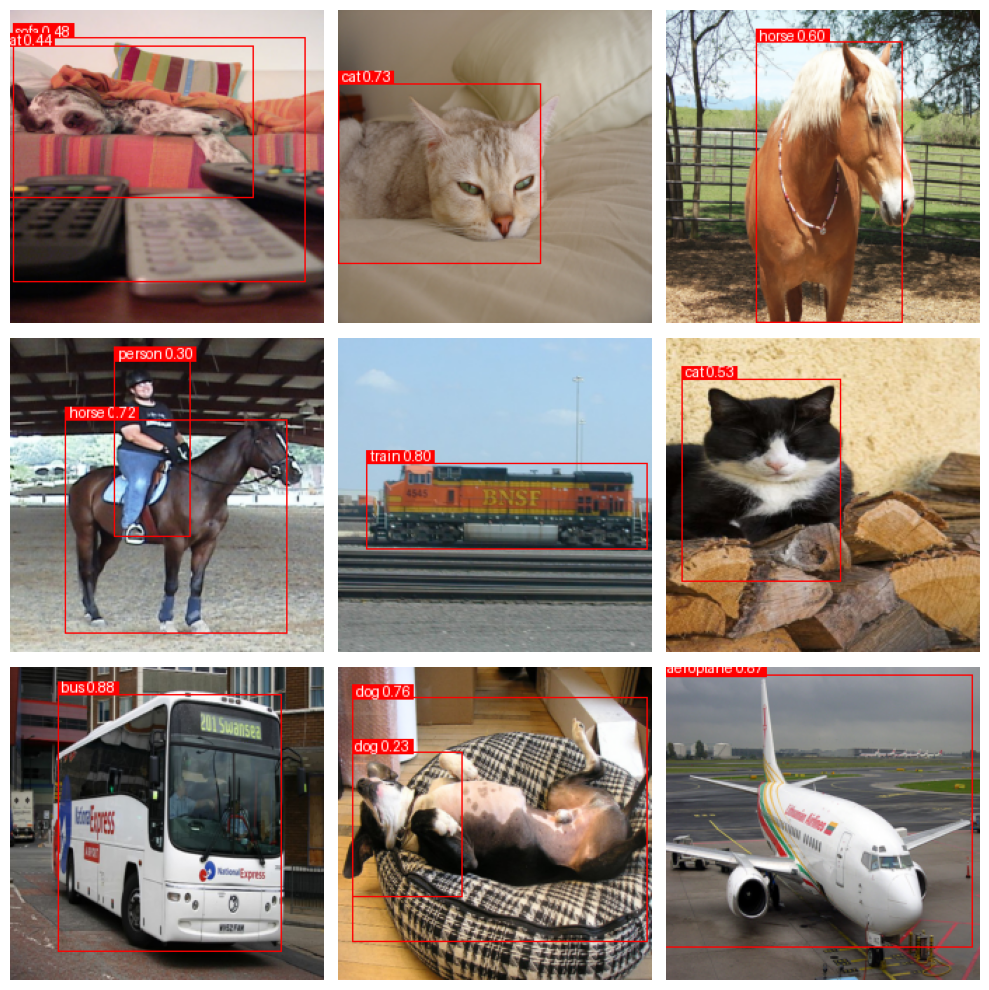

In [29]:
images_to_plot = []
bboxes_ls_list = []
classes_ls_list = []
scores_ls_list = []

vli = iter(val_loader)
for i in range(9):
    images, bboxes_ls, classes_ls, scores_ls = nms_visualize(yolonet, next(vli))
    images_to_plot.append(images)
    bboxes_ls_list.append(bboxes_ls)
    classes_ls_list.append(classes_ls)
    scores_ls_list.append(scores_ls)

plot_images(images_to_plot, bboxes_ls_list, classes_ls_list, scores_ls_list)